## Import

In [1]:
import os
import matplotlib.pyplot as plt
from monai.data import DataLoader, decollate_batch, CacheDataset
from monai.inferers import sliding_window_inference
from monai.networks.nets import UNETR
from monai.transforms import (
    Compose,
    LoadImaged,
    Orientationd,
    Invertd,
    Spacingd,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    CropForegroundd,
    ToTensord,
)
import monai
import numpy as np
import nibabel as nib
from glob import glob
import torch
from monai.utils import set_determinism
from tqdm import tqdm
from monai.transforms import Compose
import SimpleITK as sitk
import warnings
warnings.filterwarnings("ignore")
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['black', 'red', 'pink', 'cyan'])

In [2]:
# Set deterministic training for reproducibility
set_determinism(seed=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Set CUDA device order
torch.backends.cudnn.benchmark = True
root_dir = "models/"

## Data loading

In [3]:
def dice_coefficient(segmented_image: np.ndarray, gt_labels: np.ndarray, label: int) -> float:
    """Calculate Dice coefficient for a specific label.
    
    Args:
        segmented_image (np.ndarray): Predicted segmentation
        gt_labels (np.ndarray): Ground truth labels
        label (int): Label to calculate Dice coefficient for
        
    Returns:
        float: Dice coefficient value between 0 and 1
    """
    seg_mask = segmented_image == label
    gt_mask = gt_labels == label
    
    intersection = np.sum(seg_mask & gt_mask)
    denominator = np.sum(seg_mask) + np.sum(gt_mask)
    
    return (2.0 * intersection) / denominator if denominator > 0 else 0.0

def show_results(image, gt, prediction, modality='T1', i=0, slice_idx=150, plot=True, show_hist=True, cmap='tab20'):
    csf, gm, wm = dice_coefficient(prediction, gt, 1), dice_coefficient(prediction, gt, 2), dice_coefficient(prediction, gt, 3)
    print(f'Dice Score: CSF: {csf}, GM: {gm}, WM: {wm}, Avg: {(csf+gm+wm)/3}')
    if plot:
        slice_idx = slice_idx
        plt.figure(figsize=(15, 15))
        plt.subplot(1, 5, 1)
        plt.imshow(image[slice_idx], cmap='gray')
        plt.title(f'Original Image Slice for {modality} image {i+1}')
        plt.axis('off')
        
        plt.subplot(1, 5, 2)
        plt.imshow(gt[slice_idx], cmap='gray')
        plt.title('Ground Truth Slice')
        plt.axis('off')

        plt.subplot(1, 5, 3)
        plt.imshow(prediction[slice_idx], cmap='gray')
        plt.title('Segmented Image Slice')
        plt.axis('off')
        plt.tight_layout()
        
        # plot overlay
        overlay = np.zeros_like(image[slice_idx])
        overlay[prediction[slice_idx] == 1] = 1
        overlay[prediction[slice_idx] == 2] = 2
        overlay[prediction[slice_idx] == 3] = 3
        plt.subplot(1, 5, 4)
        plt.imshow(image[slice_idx], cmap='gray')
        plt.imshow(overlay, cmap=cmap, alpha=0.5)
        plt.title('Prediction Overlay')
        plt.axis('off')
        
        # ground truth overlay
        overlay_gt = np.zeros_like(image[slice_idx])
        overlay_gt[gt[slice_idx] == 1] = 1
        overlay_gt[gt[slice_idx] == 2] = 2
        overlay_gt[gt[slice_idx] == 3] = 3
        plt.subplot(1, 5, 5)
        plt.imshow(image[slice_idx], cmap='gray')
        plt.imshow(overlay_gt, cmap=cmap, alpha=0.5)
        plt.title('Ground Truth Overlay')
        plt.axis('off')
        
        if show_hist:
            # plot histogram
            plt.figure(figsize=(15, 6))
            plt.subplot(1, 3, 1)
            plt.hist(image[slice_idx].ravel(), bins=256, histtype='step', color='black')
            plt.title(f'Original Image Histogram for {modality} image {i+1}')
            plt.xlabel('Intensity')
            plt.ylabel('Frequency')
            
            plt.subplot(1, 3, 2)
            plt.hist(gt[slice_idx].ravel(), bins=256, histtype='step', color='black')
            plt.title('Ground Truth Histogram') 
            plt.xlabel('Intensity')
            plt.ylabel('Frequency')
            
            plt.subplot(1, 3, 3)
            plt.hist(prediction[slice_idx].ravel(), bins=256, histtype='step', color='black')
            plt.title('Segmented Image Histogram')
            plt.xlabel('Intensity')
            plt.ylabel('Frequency')
            plt.tight_layout()
        
        
        plt.show()
    return csf, gm, wm


In [4]:
val_root_dir = "Validation_Set"
subdirs = sorted(os.listdir(val_root_dir))
images = []
labels = []

for subdir in subdirs:
    img_path = os.path.join(val_root_dir, subdir, f"{subdir}.nii.gz")
    lbl_path = os.path.join(val_root_dir, subdir, f"{subdir}_seg.nii.gz")
    if os.path.exists(img_path) and os.path.exists(lbl_path):
        images.append(img_path)
        labels.append(lbl_path)

# Create dictionary items for each image-label pair
val_files = [{"image": img, "label": lbl} for img, lbl in zip(images, labels)]

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.5, 1.0), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityRanged(keys="image", a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image"], source_key="image"),
])

val_ds = CacheDataset(data=val_files, transform=val_transforms, cache_rate=1, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=4)


# Test data directory
test_root_dir = "Test_Set"
test_images = []
for subdir in os.listdir(test_root_dir):
    img_path = os.path.join(test_root_dir, subdir, f"{subdir}.nii.gz")
    if os.path.exists(img_path):
        test_images.append(img_path)
# Load test data and apply transforms
test_data = [{"image": img} for img in test_images]
test_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Spacingd(keys=["image"], pixdim=(1.0, 1.5, 1.0), mode=("bilinear")),
    Orientationd(keys=["image"], axcodes="RAS"),
    ScaleIntensityRanged(keys="image", a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image"], source_key="image"),
])

test_ds = CacheDataset(data=test_data, transform=test_transforms, cache_rate=1.0, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=4)

post_transforms = Compose(
    [
        Invertd(
            keys="pred",
            transform=val_transforms,
            orig_keys="image",
            meta_keys="pred_meta_dict",
            orig_meta_keys="image_meta_dict",
            meta_key_postfix="meta_dict",
            nearest_interp=False,
            to_tensor=True,
            device="cpu",
        ),

    ])

Loading dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Loading dataset: 100%|██████████| 3/3 [00:01<00:00,  1.92it/s]


## Model Development

In [5]:
# Model initialization function
def initialize_model(model_name):
    if model_name == "UNETR":
        model = UNETR(
            in_channels=1,
            out_channels=4,
            img_size=(96, 96, 96),
            feature_size=16,
            hidden_size=768,
            mlp_dim=3072,
            num_heads=12,
            proj_type="perceptron",
            norm_name="instance",
            res_block=True,
            dropout_rate=0.0,
        )
    elif model_name == "ResUNet":
        model = monai.networks.nets.UNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=4,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
            norm="instance",
        )
    elif model_name == "SwinUNETR":
        model = monai.networks.nets.SwinUNETR(
            img_size=(96, 96, 96),
            in_channels=1,
            out_channels=4,
            feature_size=48,
            use_checkpoint=True,
        )
    elif model_name == "BasicUNet":
        model = monai.networks.nets.BasicUNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=4,
            norm="instance",
        )
    else:
        raise ValueError(f"Model {model_name} is not supported.")
    return model.to(device)

def save_val_pred(model, val_loader, output_dir, model_path):
    os.makedirs(output_dir, exist_ok=True)
    model.load_state_dict(torch.load(os.path.join(root_dir, model_path), map_location=device))
    model.eval()
    with torch.no_grad():
        for val_data in val_loader:
            val_inputs = val_data["image"].to(device)

            # Get metadata directly from the input image's meta attribute
            original_affine = val_data["image"].meta["affine"][0].cpu().numpy()
            val_data["pred"] = sliding_window_inference(val_inputs, (96, 96, 96), 4, model, overlap=0.3)
            val_data = [post_transforms(i) for i in decollate_batch(val_data)]

            val_outputs = val_data[0]["pred"]

            # Post-processing and saving
            seg_map = torch.argmax(val_outputs, dim=0).detach().cpu().numpy()

            seg_img = nib.Nifti1Image(seg_map.astype(np.uint8), original_affine)

            val_image_name = os.path.basename(val_data[0]["image"].meta["filename_or_obj"])
            output_path = os.path.join(output_dir, val_image_name.replace(".nii.gz", "_pred_seg.nii.gz"))
            nib.save(seg_img, output_path)

    return f"Val predictions saved to: {output_dir}"

def test_and_save_predictions(model, test_loader, model_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    model.load_state_dict(torch.load(os.path.join(root_dir, model_path), map_location=device))
    model.eval()
    with torch.no_grad():
        for test_data in test_loader:
            test_inputs = test_data["image"].to(device)
            
            # Get metadata directly from the input image's meta attribute
            original_affine = test_data["image"].meta["affine"][0].cpu().numpy()

            test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 4, model, overlap=0.3)
            test_data = [post_transforms(i) for i in decollate_batch(test_data)]

            test_outputs = test_data[0]["pred"]

            # Post-processing and saving
            # Post-processing and saving
            seg_map = torch.argmax(test_outputs, dim=0).detach().cpu().numpy()

            seg_img = nib.Nifti1Image(seg_map.astype(np.uint8), original_affine)

            test_image_name = os.path.basename(test_data[0]["image"].meta["filename_or_obj"])
            output_path = os.path.join(output_dir, test_image_name.replace(".nii.gz", "_seg.nii.gz"))
            nib.save(seg_img, output_path)

    return f"Predictions saved to: {output_dir}"




# Results

## 3D

### Basic Unet

In [6]:
model_name = "BasicUNet"
model = initialize_model(model_name) 
model_path = os.path.join(f"best_{model_name}_model.pth")
output_dir = os.path.join("BasicUNet_Val_Preds")
save_val_pred(model, val_loader, output_dir, model_path)

BasicUNet features: (32, 32, 64, 128, 256, 32).


'Val predictions saved to: BasicUNet_Val_Preds'

Dice Score: CSF: 0.8467486033519553, GM: 0.9360068611754854, WM: 0.9478985316472897, Avg: 0.9102179987249102


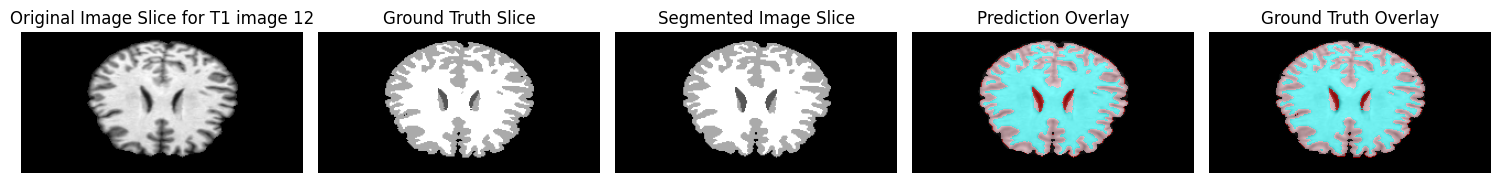

Dice Score: CSF: 0.8960160187806394, GM: 0.9228997826015948, WM: 0.926059143997474, Avg: 0.9149916484599028


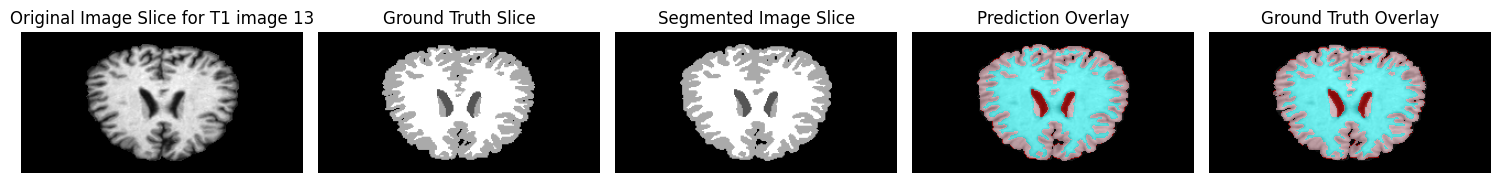

Dice Score: CSF: 0.8528125138084928, GM: 0.9207317902239525, WM: 0.8940009831508843, Avg: 0.8891817623944432


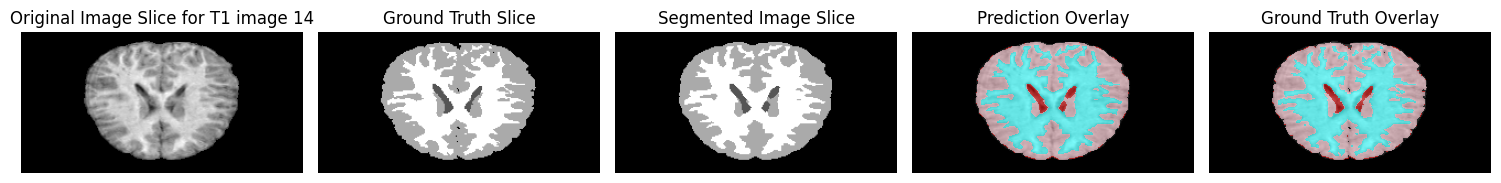

Dice Score: CSF: 0.8942202835332607, GM: 0.9419504522105288, WM: 0.932930164959733, Avg: 0.9230336335678407


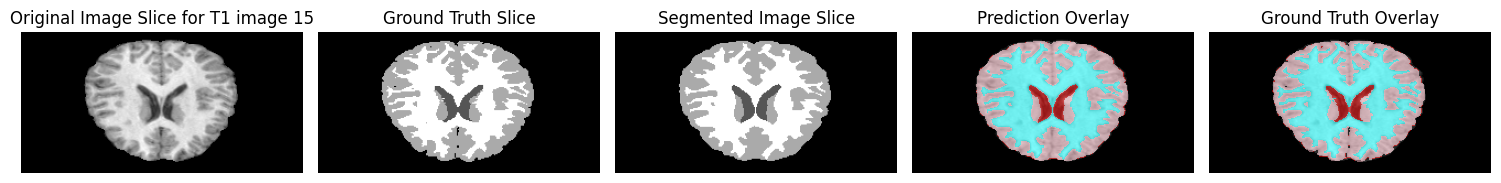

Dice Score: CSF: 0.921410071373495, GM: 0.9384192700788266, WM: 0.9177989044358943, Avg: 0.9258760819627385


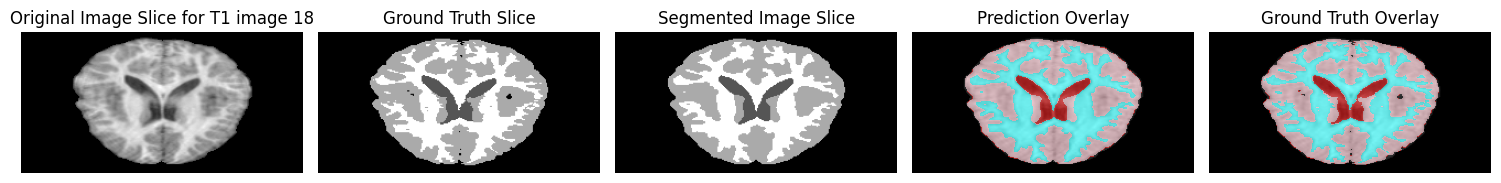

In [6]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"BasicUNet_Val_Preds/IBSR_{idx}_pred_seg.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

In [10]:
model_name = "BasicUNet"
model = initialize_model(model_name) 
model_path = os.path.join(f"best_{model_name}_model.pth")
output_dir = os.path.join("BasicUNet_Test_Preds")
test_and_save_predictions(model, test_loader, model_path, output_dir)

BasicUNet features: (32, 32, 64, 128, 256, 32).


'Predictions saved to: BasicUNet_Test_Preds'

### ResUNet

In [8]:
model_name = "ResUNet"
model = initialize_model(model_name)
model_path = os.path.join(f"best_{model_name}_model.pth")
output_dir = os.path.join("ResUNet_Val_Preds")
save_val_pred(model, val_loader, output_dir, model_path)

'Val predictions saved to: ResUNet_Val_Preds'

Dice Score: CSF: 0.8077276908923643, GM: 0.9120253444365745, WM: 0.9220208155388947, Avg: 0.8805912836226112


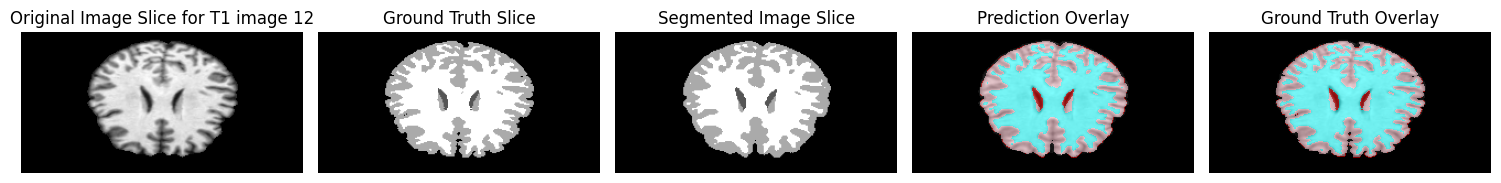

Dice Score: CSF: 0.8630778035888631, GM: 0.9023608033672371, WM: 0.9056374324164996, Avg: 0.8903586797908666


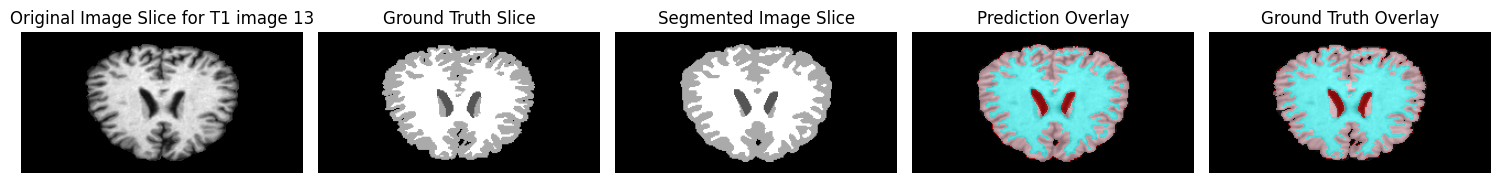

Dice Score: CSF: 0.7839955232232793, GM: 0.9085163663446634, WM: 0.8750235915057564, Avg: 0.8558451603578997


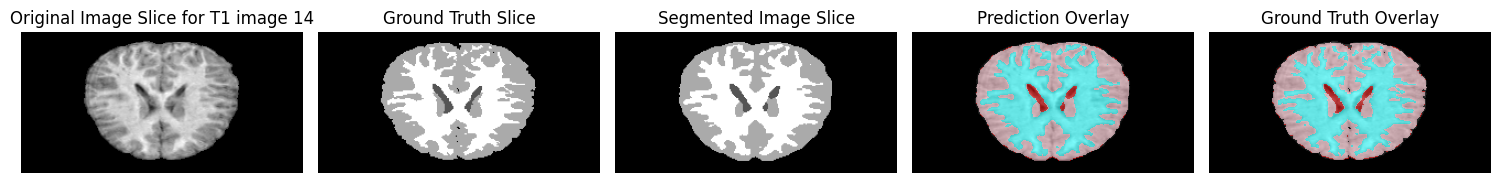

Dice Score: CSF: 0.8326567433468651, GM: 0.9231493314790675, WM: 0.9089235477092132, Avg: 0.8882432075117154


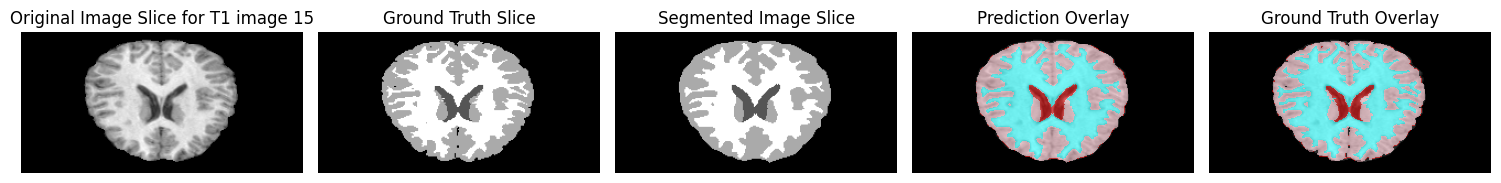

Dice Score: CSF: 0.8663321912220591, GM: 0.9258796346642871, WM: 0.8969624024711517, Avg: 0.8963914094524993


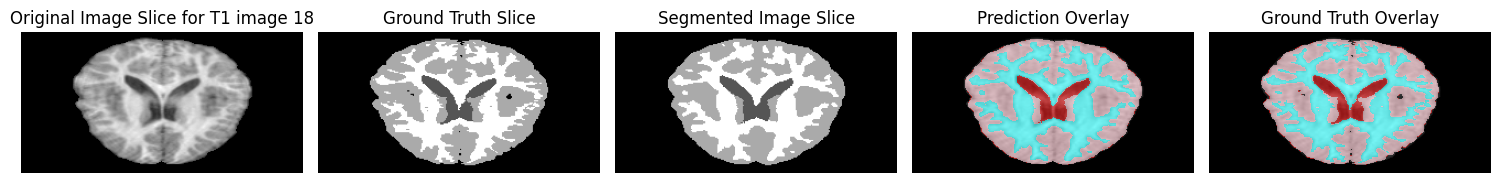

In [7]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"ResUNet_Val_Preds/IBSR_{idx}_pred_seg.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

In [11]:
model_name = "ResUNet"
model = initialize_model(model_name) 
model_path = os.path.join(f"best_{model_name}_model.pth")
output_dir = os.path.join("ResUNet_Test_Preds")
test_and_save_predictions(model, test_loader, model_path, output_dir)

'Predictions saved to: ResUNet_Test_Preds'

### UNETR

In [6]:
model_name = "UNETR"
model = initialize_model(model_name) 
model_path = os.path.join(f"best_{model_name}_model.pth")
output_dir = os.path.join("UNETR_Val_Preds")
save_val_pred(model, val_loader, output_dir, model_path)

'Val predictions saved to: UNETR_Val_Preds'

Dice Score: CSF: 0.7095030655050016, GM: 0.9038361784289252, WM: 0.913263485587932, Avg: 0.8422009098406195


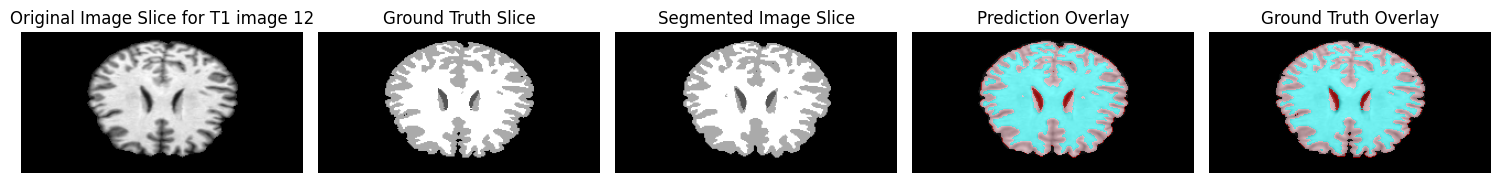

Dice Score: CSF: 0.8721086691869033, GM: 0.9134756410267925, WM: 0.9205882058520276, Avg: 0.902057505355241


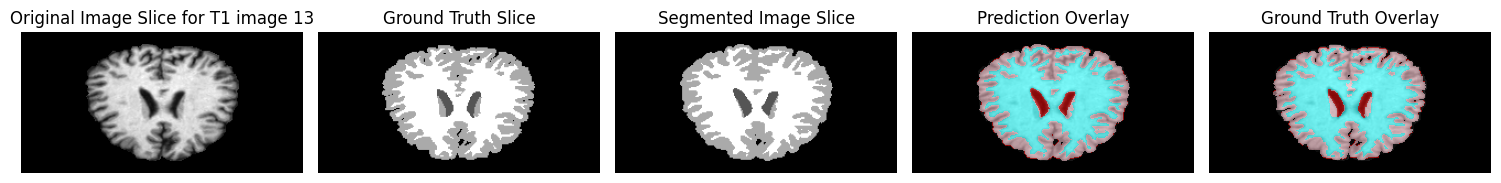

Dice Score: CSF: 0.7856149948432806, GM: 0.907509733976825, WM: 0.8787083177052636, Avg: 0.857277682175123


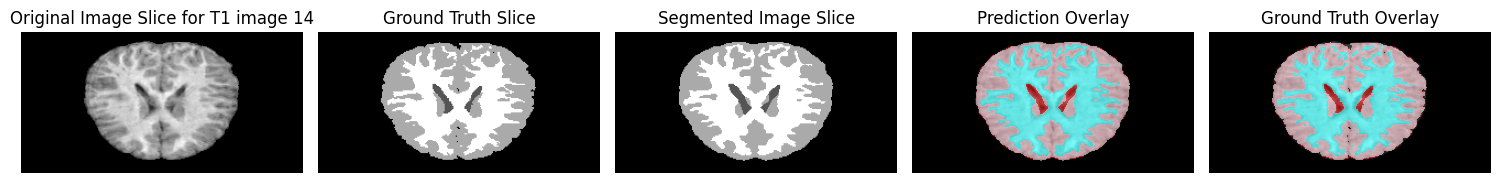

Dice Score: CSF: 0.8342860985943911, GM: 0.9338732601881539, WM: 0.9313337991876665, Avg: 0.8998310526567371


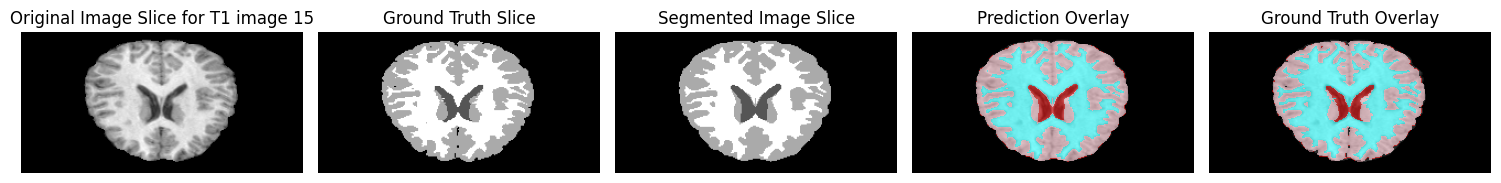

Dice Score: CSF: 0.8660406949508117, GM: 0.9327008871996099, WM: 0.9123696780367705, Avg: 0.9037037533957307


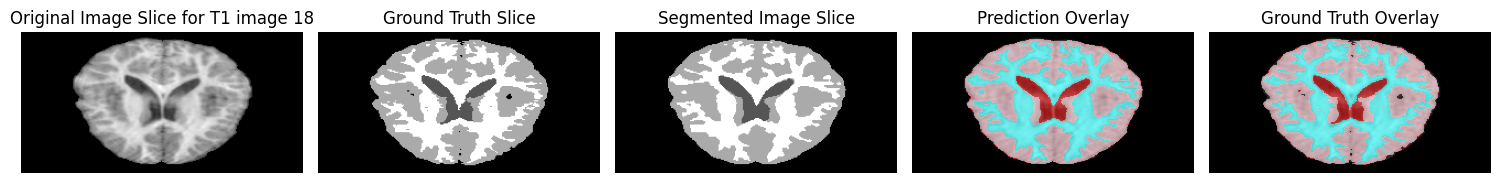

In [8]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"UNETR_Val_Preds/IBSR_{idx}_pred_seg.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

In [12]:
model_name = "UNETR"
model = initialize_model(model_name) 
model_path = os.path.join(f"best_{model_name}_model.pth")
output_dir = os.path.join("UNETR_Test_Preds")
test_and_save_predictions(model, test_loader, model_path, output_dir)

'Predictions saved to: UNETR_Test_Preds'

### SwinUNETR

In [10]:
model_name = "SwinUNETR"
model = initialize_model(model_name)
model_path = os.path.join(f"best_{model_name}_model.pth")
output_dir = os.path.join("SwinUNETR_Val_Preds")
save_val_pred(model, val_loader, output_dir, model_path) 

'Val predictions saved to: SwinUNETR_Val_Preds'

Dice Score: CSF: 0.7058598823439529, GM: 0.9176062694307942, WM: 0.9226425219117058, Avg: 0.8487028912288176


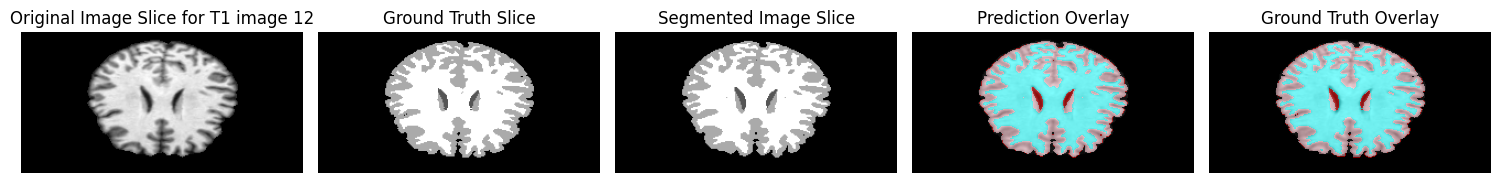

Dice Score: CSF: 0.880632011832185, GM: 0.9198670788170122, WM: 0.9206165202647559, Avg: 0.9070385369713178


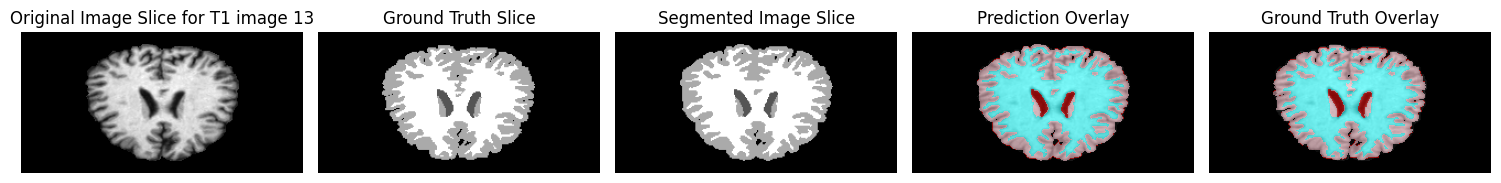

Dice Score: CSF: 0.8330725601408175, GM: 0.920578447303252, WM: 0.8915665827323903, Avg: 0.8817391967254866


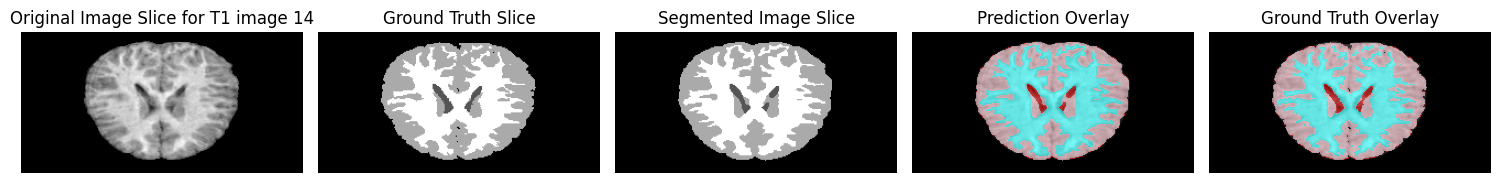

Dice Score: CSF: 0.9054788029016149, GM: 0.944618312913714, WM: 0.9357886639008709, Avg: 0.9286285932387331


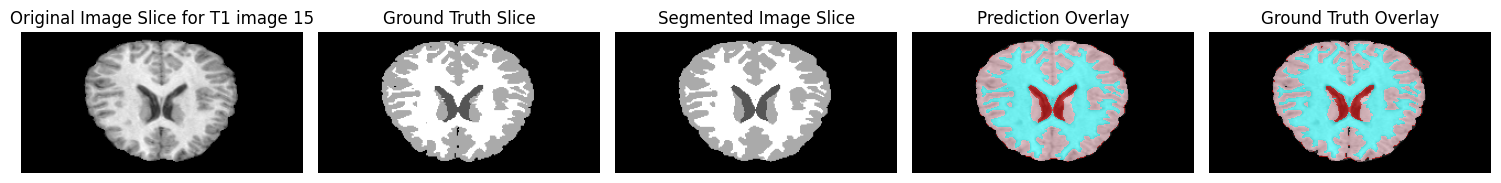

Dice Score: CSF: 0.9083340376975741, GM: 0.9417444186921812, WM: 0.9206899644255777, Avg: 0.923589473605111


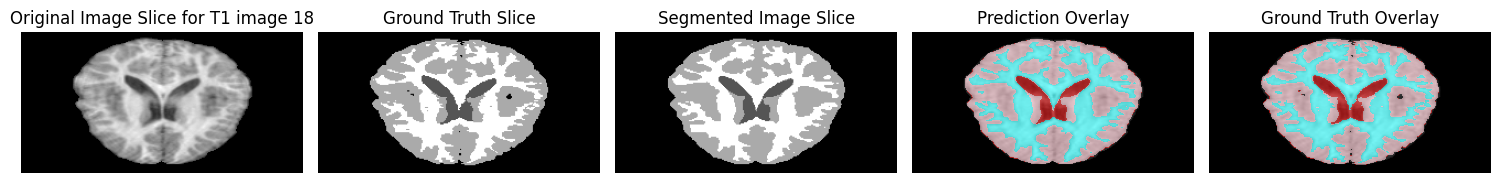

In [9]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"SwinUNETR_Val_Preds/IBSR_{idx}_pred_seg.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

In [13]:
model_name = "SwinUNETR"
model = initialize_model(model_name) 
model_path = os.path.join(f"best_{model_name}_model.pth")
output_dir = os.path.join("SwinUNETR_Test_Preds")
test_and_save_predictions(model, test_loader, model_path, output_dir)

'Predictions saved to: SwinUNETR_Test_Preds'

## 2.5D

### Basic Unet

Dice Score: CSF: 0.8821030270844398, GM: 0.9291726301989396, WM: 0.9464197736516008, Avg: 0.91923181031166


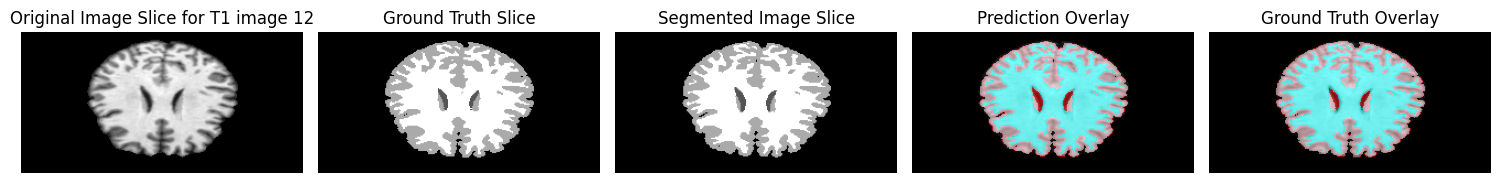

Dice Score: CSF: 0.9007855885141541, GM: 0.9180498810847131, WM: 0.9191103579189167, Avg: 0.9126486091725946


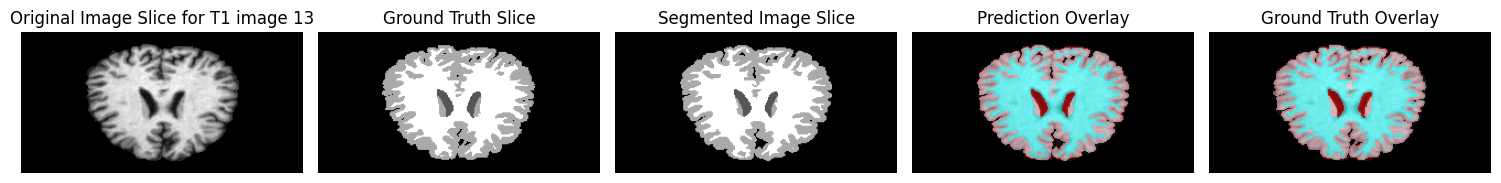

Dice Score: CSF: 0.8630434782608696, GM: 0.9329977059360577, WM: 0.909431624487449, Avg: 0.9018242695614588


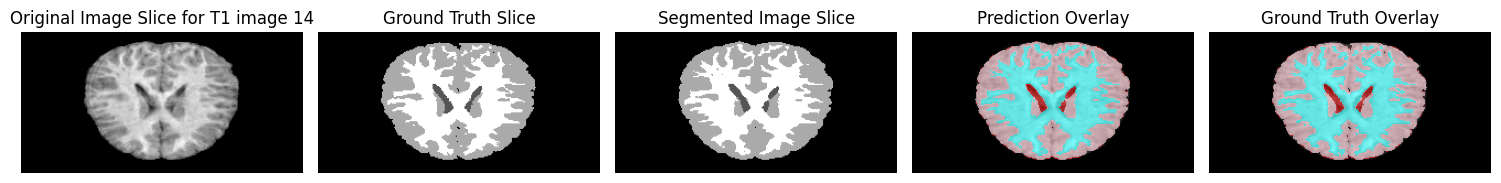

Dice Score: CSF: 0.904971851047955, GM: 0.9473087083838425, WM: 0.9381812899317785, Avg: 0.9301539497878587


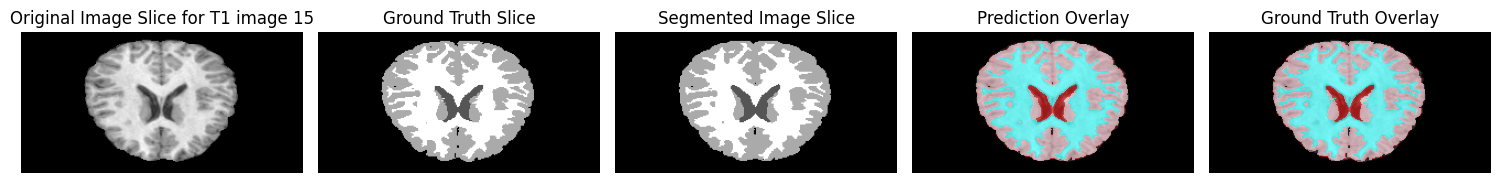

Dice Score: CSF: 0.9112813637234246, GM: 0.93666801408222, WM: 0.9107640139598203, Avg: 0.9195711305884883


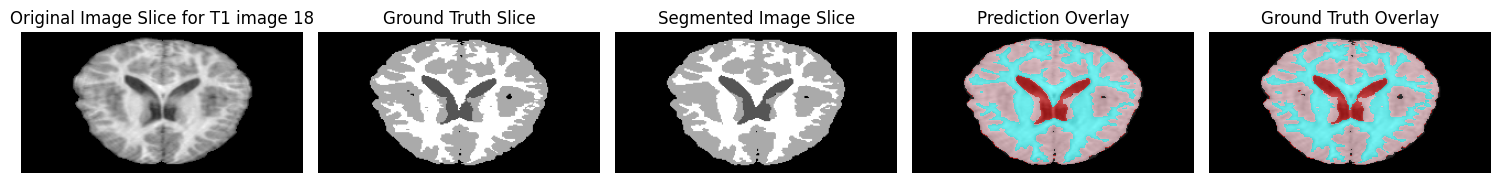

In [10]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"BasicUNet2.5D_Val_Preds/IBSR_{idx}_2.5D_prediction.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

### ResUnet

Dice Score: CSF: 0.824296499656829, GM: 0.9043277131668009, WM: 0.9236615448923784, Avg: 0.8840952525720027


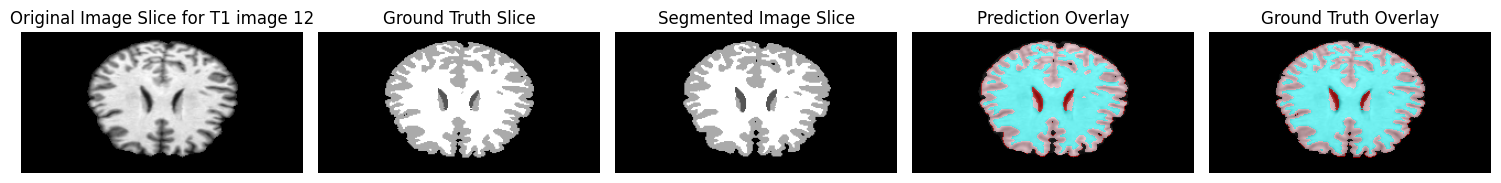

Dice Score: CSF: 0.8669895183760117, GM: 0.905058961495863, WM: 0.9134369021301911, Avg: 0.8951617940006885


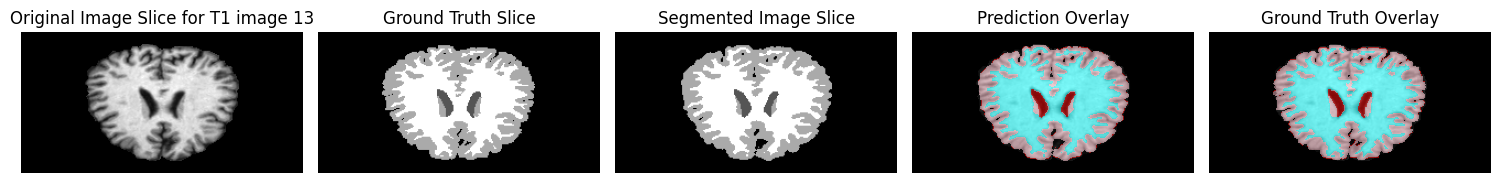

Dice Score: CSF: 0.8301258992805756, GM: 0.9240102467577959, WM: 0.8975540117410162, Avg: 0.8838967192597958


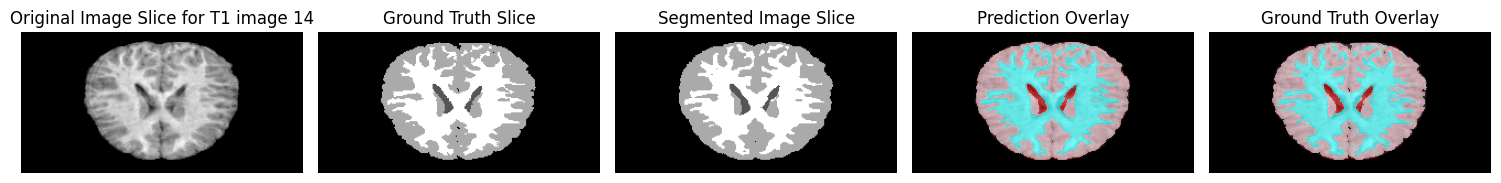

Dice Score: CSF: 0.8775749455702563, GM: 0.9346473308362846, WM: 0.9218997778792113, Avg: 0.9113740180952506


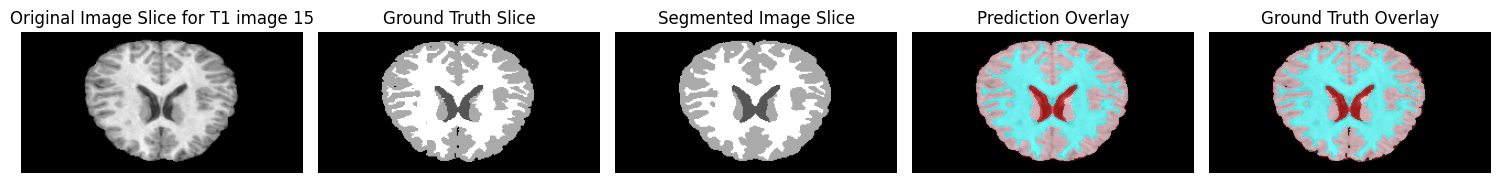

Dice Score: CSF: 0.8717476951382918, GM: 0.9305458134926575, WM: 0.9009665777670685, Avg: 0.901086695466006


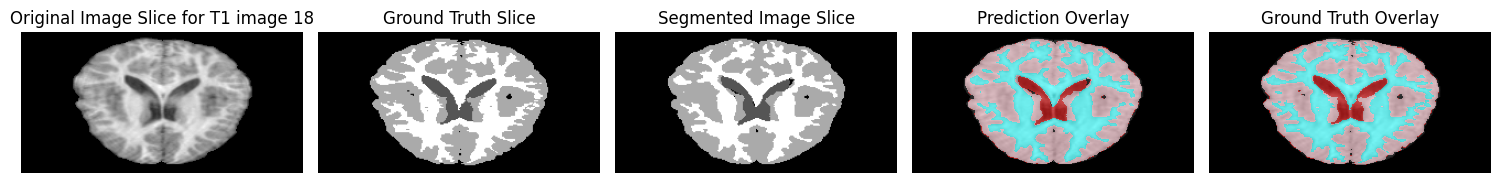

In [11]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"ResUNet2.5D_Val_Preds/IBSR_{idx}_2.5D_prediction.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

### UNETR

Dice Score: CSF: 0.5287147591592137, GM: 0.8671991303484821, WM: 0.8564219056059941, Avg: 0.75077859837123


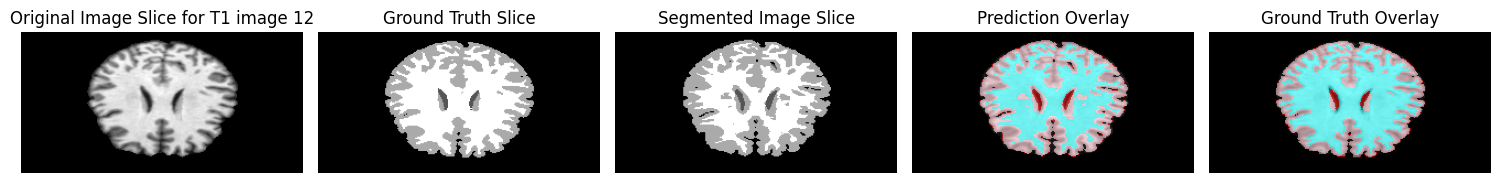

Dice Score: CSF: 0.8727038764677497, GM: 0.9167159664893072, WM: 0.9215778144693505, Avg: 0.9036658858088025


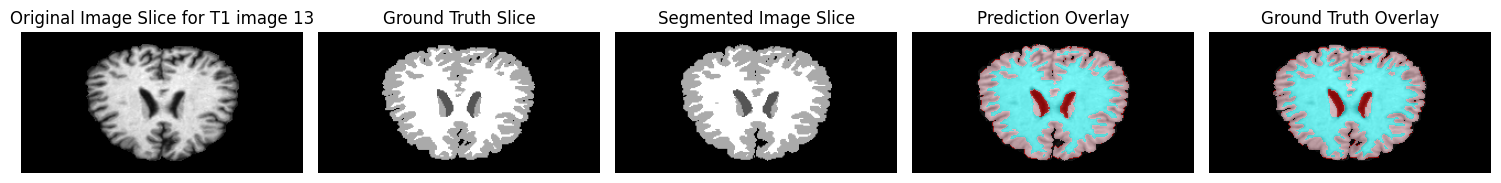

Dice Score: CSF: 0.8229205792746547, GM: 0.9268538926213967, WM: 0.9002467736249455, Avg: 0.8833404151736657


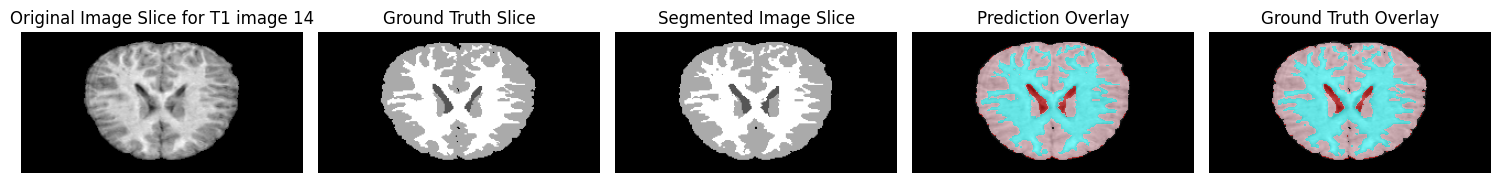

Dice Score: CSF: 0.8587672825946505, GM: 0.9351360205389362, WM: 0.9176657111512192, Avg: 0.9038563380949354


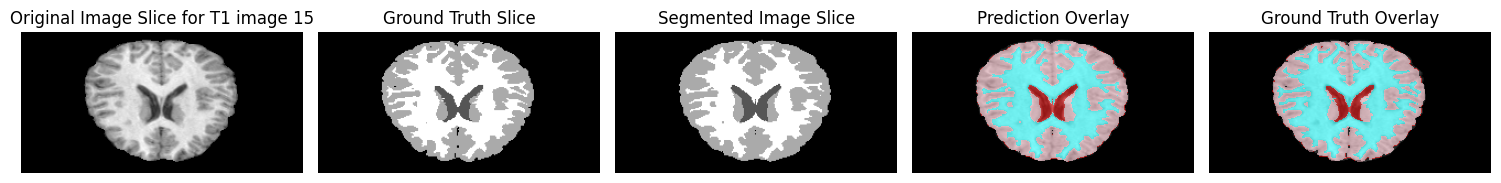

Dice Score: CSF: 0.8616605249304354, GM: 0.9288729570208609, WM: 0.8961864961878062, Avg: 0.8955733260463675


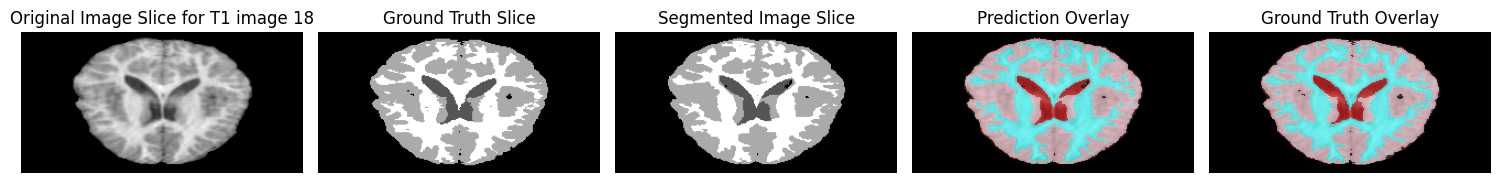

In [12]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"UNETR2.5D_Val_Preds/IBSR_{idx}_2.5D_prediction.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

### SwinUNETR

Dice Score: CSF: 0.5177196608849346, GM: 0.8446653634037413, WM: 0.8773693622665886, Avg: 0.7465847955184216


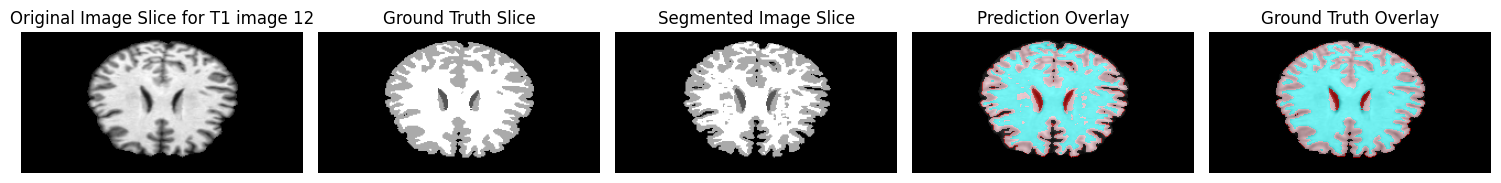

Dice Score: CSF: 0.8950835586991194, GM: 0.9201244210862527, WM: 0.9274372429055155, Avg: 0.9142150742302958


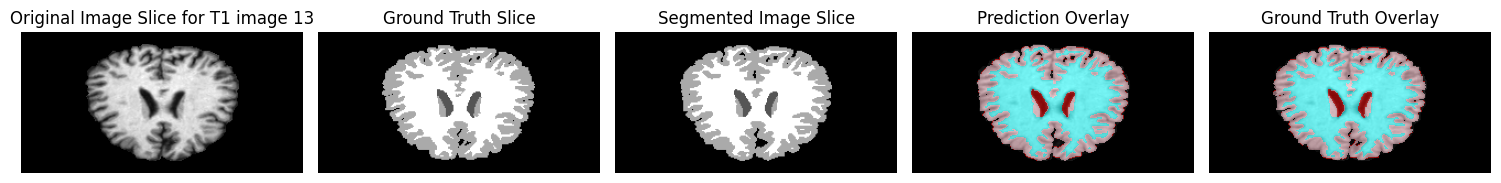

Dice Score: CSF: 0.865579988260261, GM: 0.9292886123427909, WM: 0.9030615886005185, Avg: 0.8993100630678569


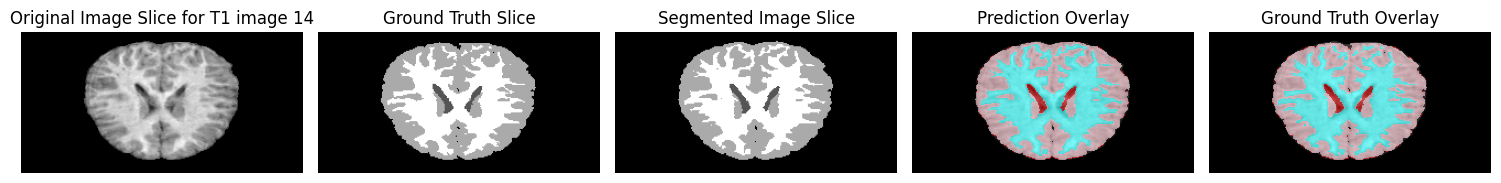

Dice Score: CSF: 0.911841881070029, GM: 0.9461769379685194, WM: 0.9369070404692729, Avg: 0.9316419531692738


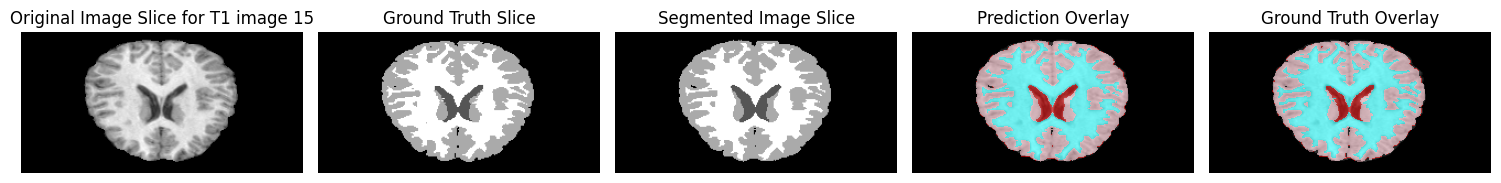

Dice Score: CSF: 0.8978693037006831, GM: 0.9293618190724225, WM: 0.8976449857875985, Avg: 0.9082920361869015


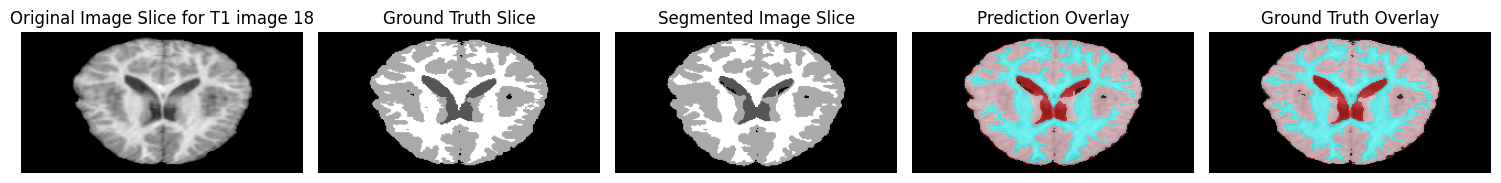

In [13]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"SwinUNETR2.5D_Val_Preds/IBSR_{idx}_2.5D_prediction.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

### ResUNEtv2

Dice Score: CSF: 0.7718964893231994, GM: 0.906745886184191, WM: 0.9216604450541478, Avg: 0.8667676068538461


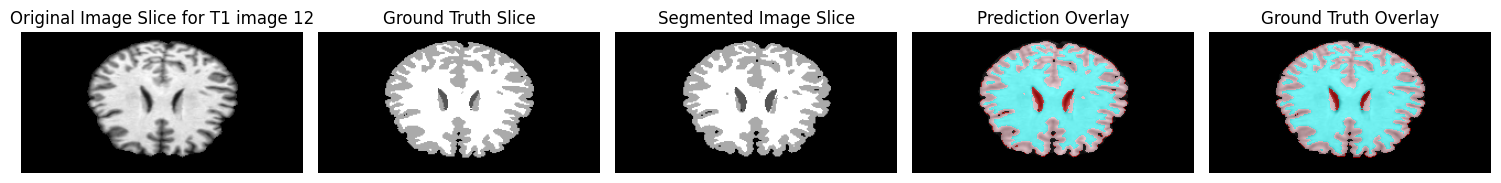

Dice Score: CSF: 0.7872792027916682, GM: 0.9126142753679186, WM: 0.9127966285788764, Avg: 0.8708967022461543


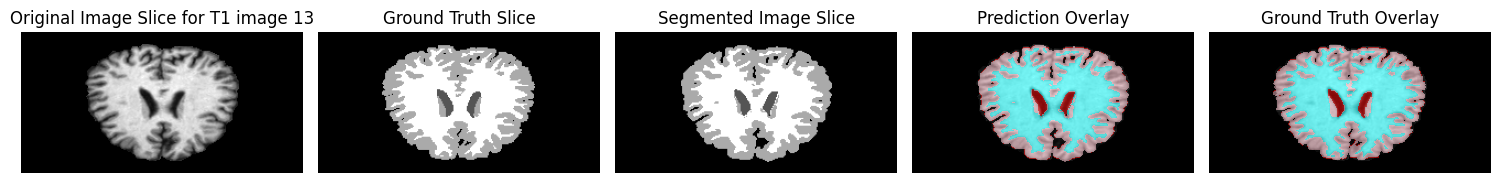

Dice Score: CSF: 0.7495194786929821, GM: 0.9206115970361738, WM: 0.8921034146007162, Avg: 0.8540781634432907


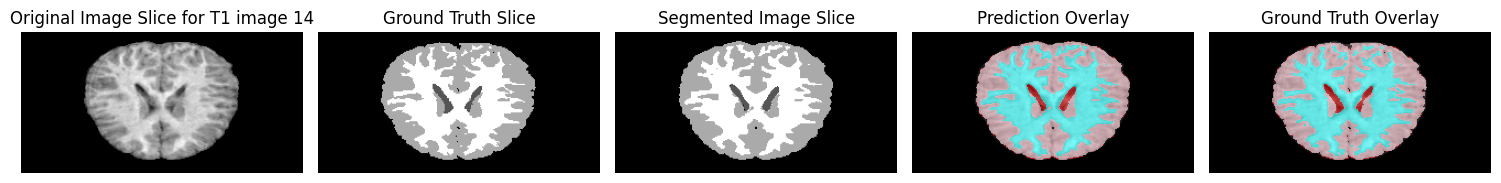

Dice Score: CSF: 0.8204122387846802, GM: 0.934895853622087, WM: 0.9213535543918624, Avg: 0.8922205489328765


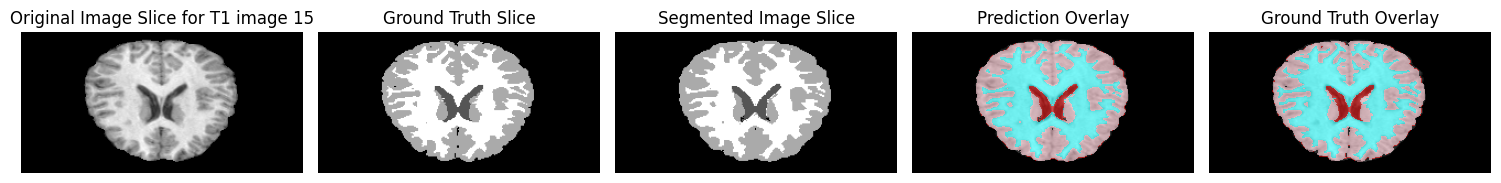

Dice Score: CSF: 0.6892329511878028, GM: 0.9238928492669377, WM: 0.8907846941103754, Avg: 0.8346368315217053


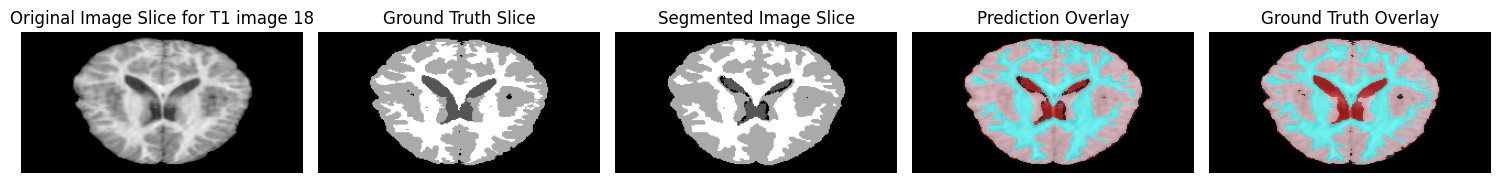

In [14]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"ResUNetv22.5D_Val_Preds/IBSR_{idx}_2.5D_prediction.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

### BasicUnet++

Dice Score: CSF: 0.8695027822653024, GM: 0.9242602296370501, WM: 0.9436719526422677, Avg: 0.9124783215148735


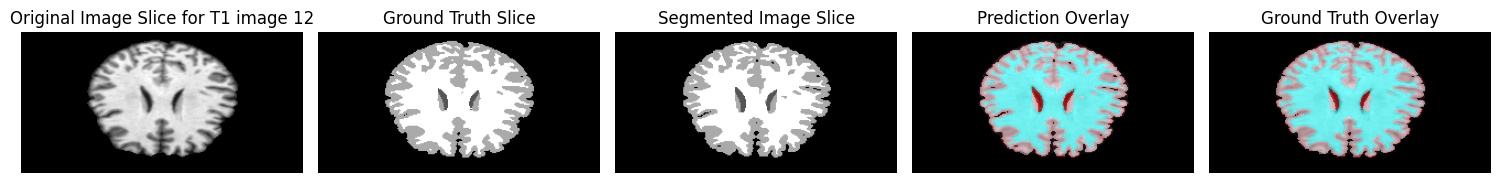

Dice Score: CSF: 0.9031124328343078, GM: 0.9224044925672837, WM: 0.9263774908105198, Avg: 0.9172981387373703


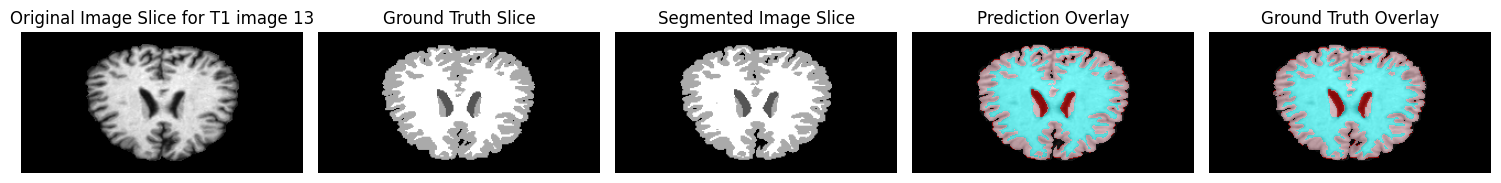

Dice Score: CSF: 0.8683660305173718, GM: 0.9370876820505275, WM: 0.913785055615295, Avg: 0.9064129227277314


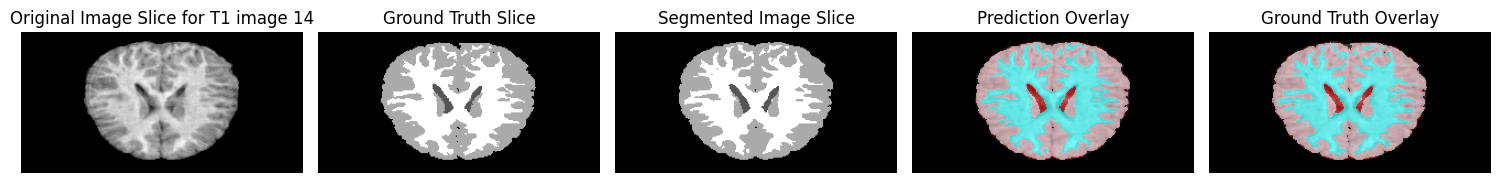

Dice Score: CSF: 0.9051991897366645, GM: 0.9480613736929144, WM: 0.9375805789663506, Avg: 0.9302803807986432


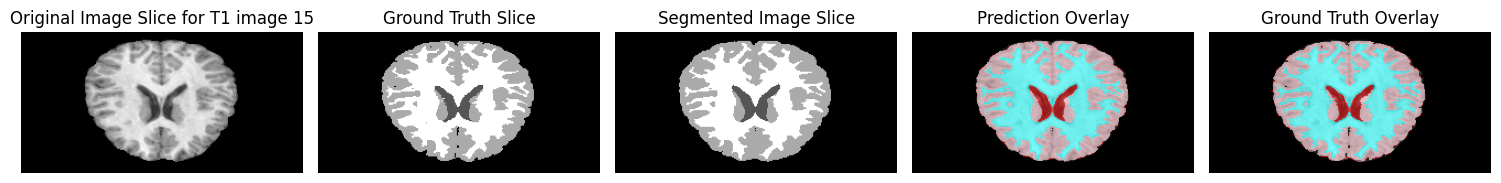

Dice Score: CSF: 0.9109302502472046, GM: 0.9385570212503439, WM: 0.9110616170937744, Avg: 0.9201829628637744


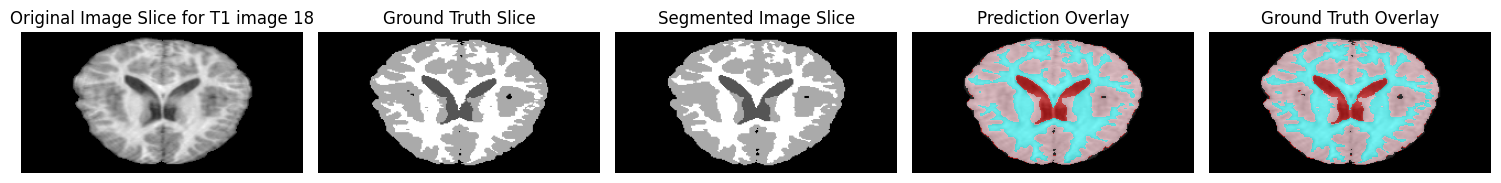

In [15]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"BasicUNetPP2.5D_Val_Preds/IBSR_{idx}_2.5D_prediction.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

### BasicUNET + Focal

Dice Score: CSF: 0.8765141766872254, GM: 0.9220913572451978, WM: 0.9437076982336433, Avg: 0.9141044107220222


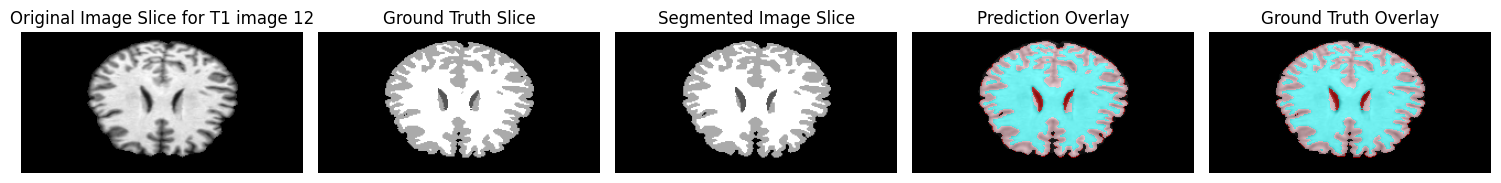

Dice Score: CSF: 0.8866306107685418, GM: 0.9154561720308494, WM: 0.9173151442134971, Avg: 0.9064673090042961


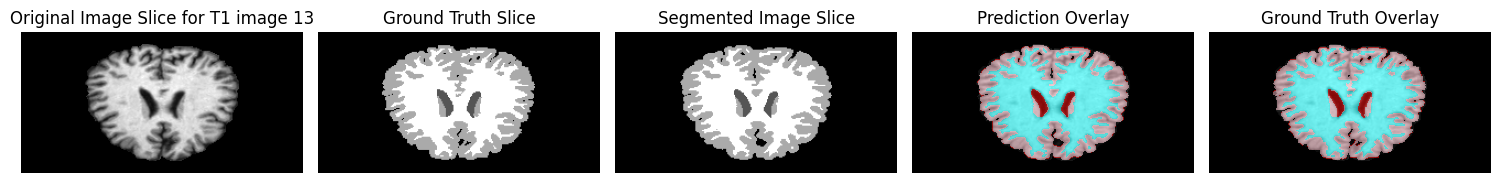

Dice Score: CSF: 0.8552619713229327, GM: 0.9273565026551391, WM: 0.8999927981281832, Avg: 0.8942037573687517


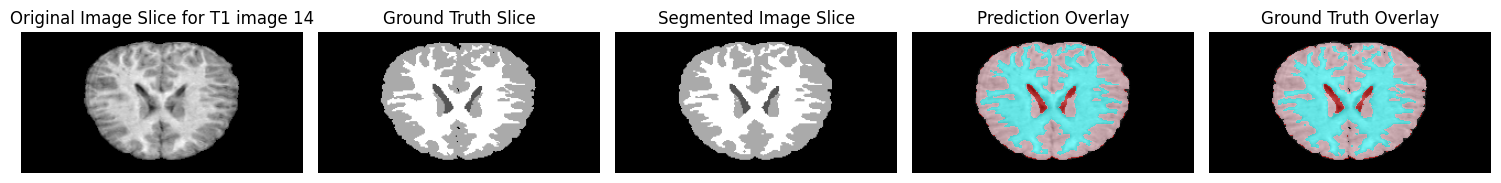

Dice Score: CSF: 0.9040008213833465, GM: 0.9459902176434302, WM: 0.9374893493861189, Avg: 0.9291601294709652


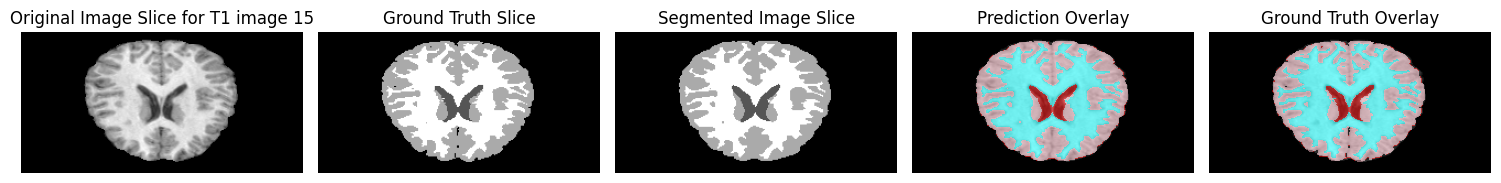

Dice Score: CSF: 0.8887288861212734, GM: 0.9333419799614394, WM: 0.9084859774838333, Avg: 0.9101856145221819


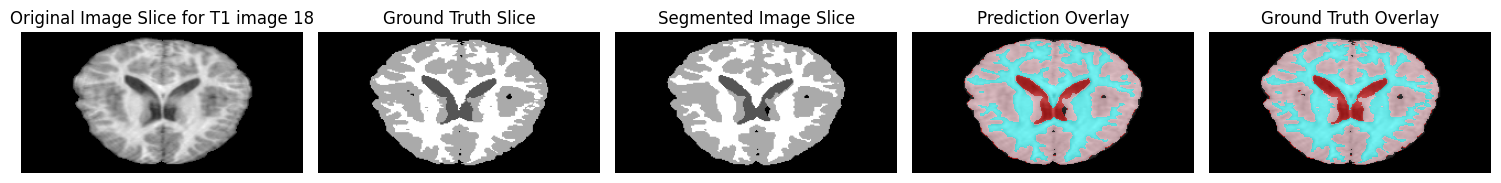

In [5]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"BasicUNet2.5D_focaldice_Val_Preds/IBSR_{idx}_2.5D_prediction.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

# Ensemble Model

Dice Score: CSF: 0.8780422928580929, GM: 0.9355861776798953, WM: 0.9513331373391528, Avg: 0.9216538692923804


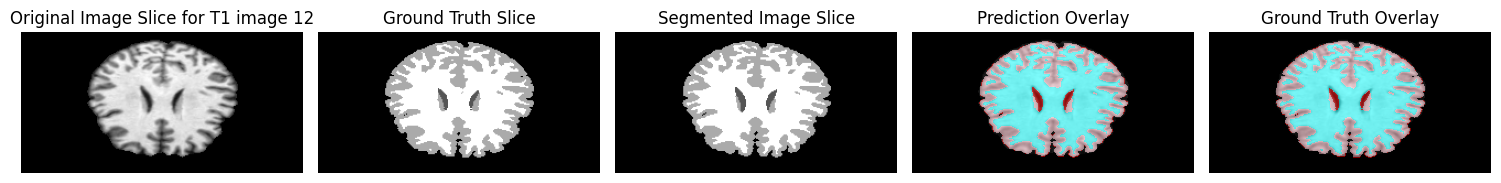

Dice Score: CSF: 0.9033558881826259, GM: 0.9249759907804597, WM: 0.9269550052435805, Avg: 0.918428961402222


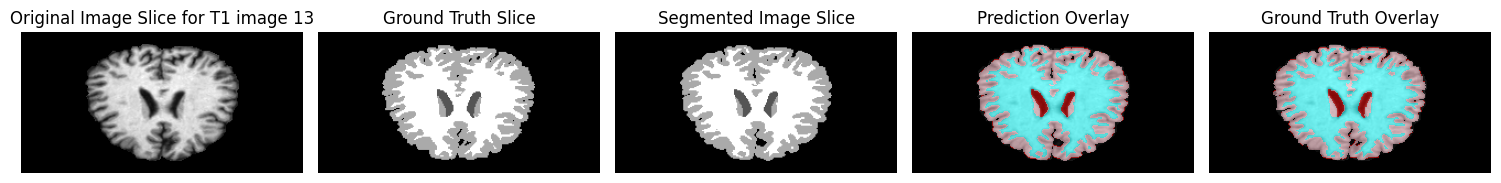

Dice Score: CSF: 0.8670417001517993, GM: 0.9326983267273458, WM: 0.9097998466567128, Avg: 0.9031799578452859


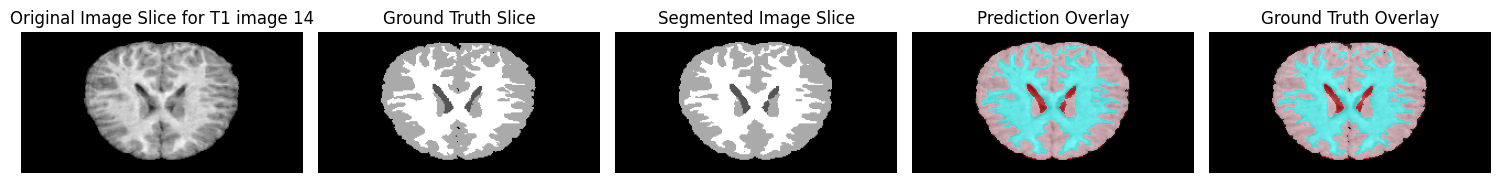

Dice Score: CSF: 0.9099793016864036, GM: 0.9503677180594557, WM: 0.9427964138757937, Avg: 0.9343811445405511


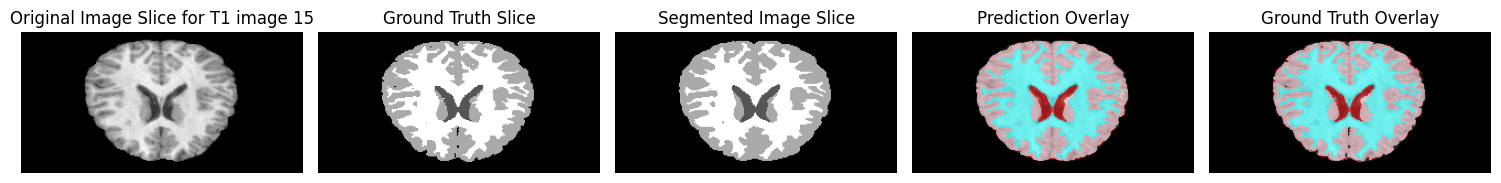

Dice Score: CSF: 0.9215110664761096, GM: 0.9437054670752436, WM: 0.923926077146234, Avg: 0.9297142035658624


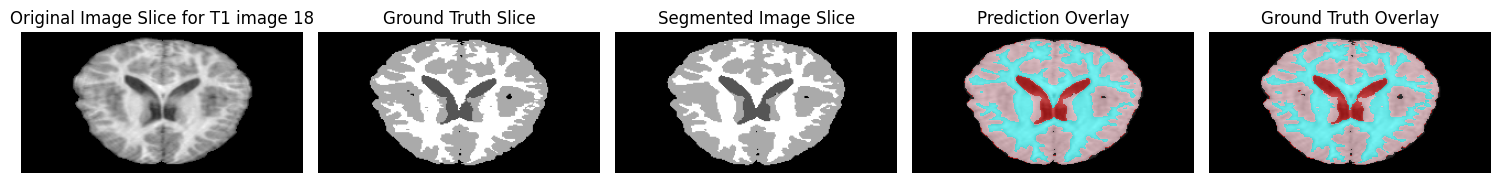

In [9]:
# Enesmble predictions
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        pred1 = sitk.GetArrayFromImage(sitk.ReadImage(f"BasicUNet2.5D_Val_Preds/IBSR_{idx}_2.5D_prediction.nii.gz"))
        pred2 = sitk.GetArrayFromImage(sitk.ReadImage(f"BasicUNet_Val_Preds/IBSR_{idx}_pred_seg.nii.gz"))
        pred3 = sitk.GetArrayFromImage(sitk.ReadImage(f"BasicUNet2.5D_focaldice_Val_Preds/IBSR_{idx}_2.5D_prediction.nii.gz"))
        # get the mode of the predictions
        ensemble_pred = np.zeros_like(pred1)
        for i in range(ensemble_pred.shape[0]):
            for j in range(ensemble_pred.shape[1]):
                for k in range(ensemble_pred.shape[2]):
                    ensemble_pred[i, j, k] = np.argmax(np.bincount([pred1[i, j, k], pred2[i, j, k], pred3[i, j, k]]))
        show_results(val_image, gt_label, ensemble_pred, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap=custom_cmap)
    except Exception as e:
        print(f"Error: {e}")

In [11]:
# Enesmble predictions of test set
for idx in [10, 15, '02']:
    pred1 = sitk.GetArrayFromImage(sitk.ReadImage(f"BasicUNet2.5D_Test_Preds/IBSR_{idx}_2.5D_prediction.nii.gz"))
    pred2 = sitk.GetArrayFromImage(sitk.ReadImage(f"BasicUNet_Test_Preds/IBSR_{idx}_seg.nii.gz"))
    pred3 = sitk.GetArrayFromImage(sitk.ReadImage(f"BasicUNet2.5D_focaldice_Test_Preds/IBSR_{idx}_2.5D_prediction.nii.gz"))
    # get the mode of the predictions
    ensemble_pred = np.zeros_like(pred1)
    for i in range(ensemble_pred.shape[0]):
        for j in range(ensemble_pred.shape[1]):
            for k in range(ensemble_pred.shape[2]):
                ensemble_pred[i, j, k] = np.argmax(np.bincount([pred1[i, j, k], pred2[i, j, k], pred3[i, j, k]]))
    # save the ensemble prediction
    ensemble_pred_img = sitk.GetImageFromArray(ensemble_pred)
    pred1_img = sitk.GetImageFromArray(pred1)
    ensemble_pred_img.CopyInformation(pred1_img)
    os.makedirs("Ensemble_Test_Preds", exist_ok=True)
    sitk.WriteImage(ensemble_pred_img, f"Ensemble_Test_Preds/IBSR_{idx}_ensemble_prediction.nii.gz")
    print(f"Ensemble prediction saved for IBSR_{idx}")
    

Ensemble prediction saved for IBSR_10
Ensemble prediction saved for IBSR_15
Ensemble prediction saved for IBSR_02


# Result Analysis

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## 3D

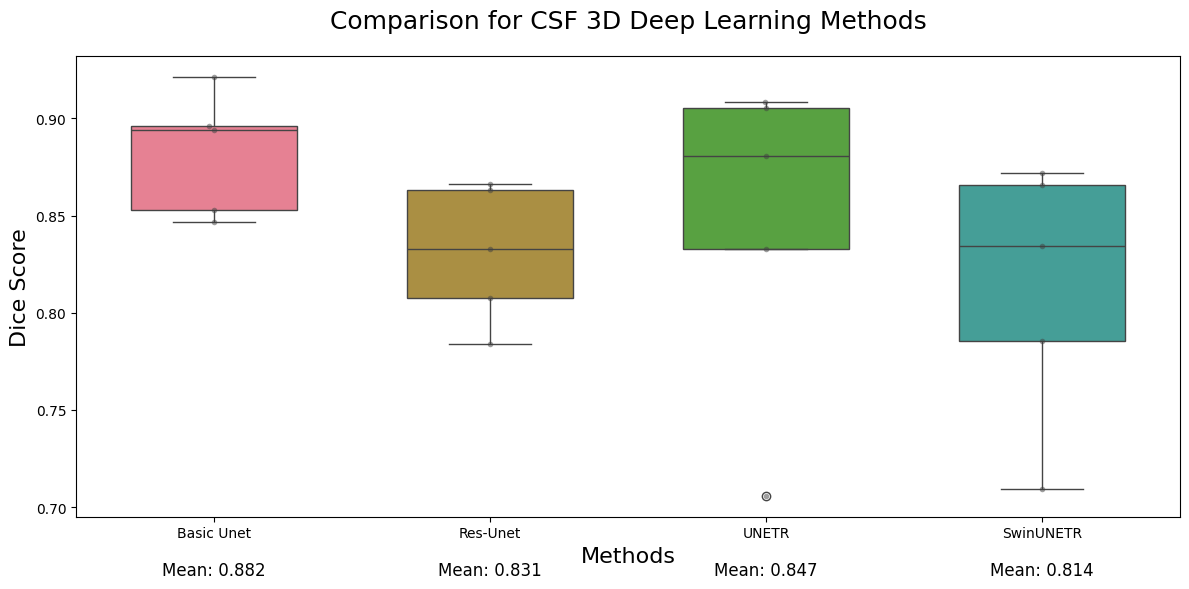

In [9]:
csf_values_unet  = [0.8467,0.8960,0.8528,0.8942,0.9214,]
csf_values_resunet = [0.8077,0.8631,0.7840,0.8327,0.8663,]
csf_values_unetr = [0.7059,0.8806,0.8331,0.9055,0.9083,]
csf_values_swinunetr = [0.7095,0.8721,0.7856,0.8343,0.8660,]

data = {
    'Basic Unet': csf_values_unet,
    'Res-Unet': csf_values_resunet,
    'UNETR': csf_values_unetr,
    'SwinUNETR': csf_values_swinunetr,

}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for CSF 3D Deep Learning Methods', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Methods', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.03, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

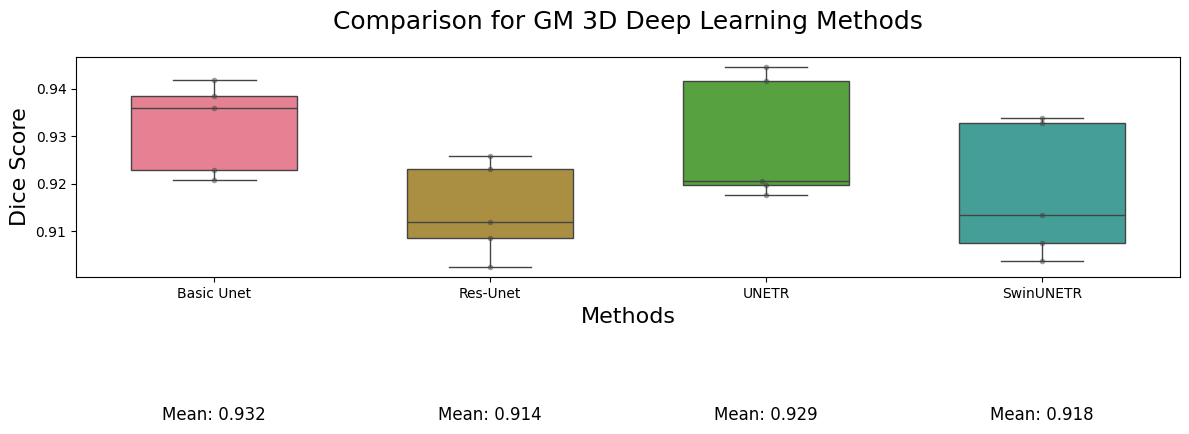

In [10]:
gm_values_unet = [0.9360,0.9228,0.9207,0.9419,0.9384,]
gm_values_resunet = [0.9120,0.9024,0.9085,0.9231,0.9259,]
gm_values_unetr = [0.9176,0.9198,0.9206,0.9446,0.9417,]
gm_values_swinunetr = [0.9038,0.9135,0.9075,0.9339,0.9327,]
data = {
    'Basic Unet': gm_values_unet,
    'Res-Unet': gm_values_resunet,
    'UNETR': gm_values_unetr,
    'SwinUNETR': gm_values_swinunetr,

}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for GM 3D Deep Learning Methods', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Methods', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.03, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

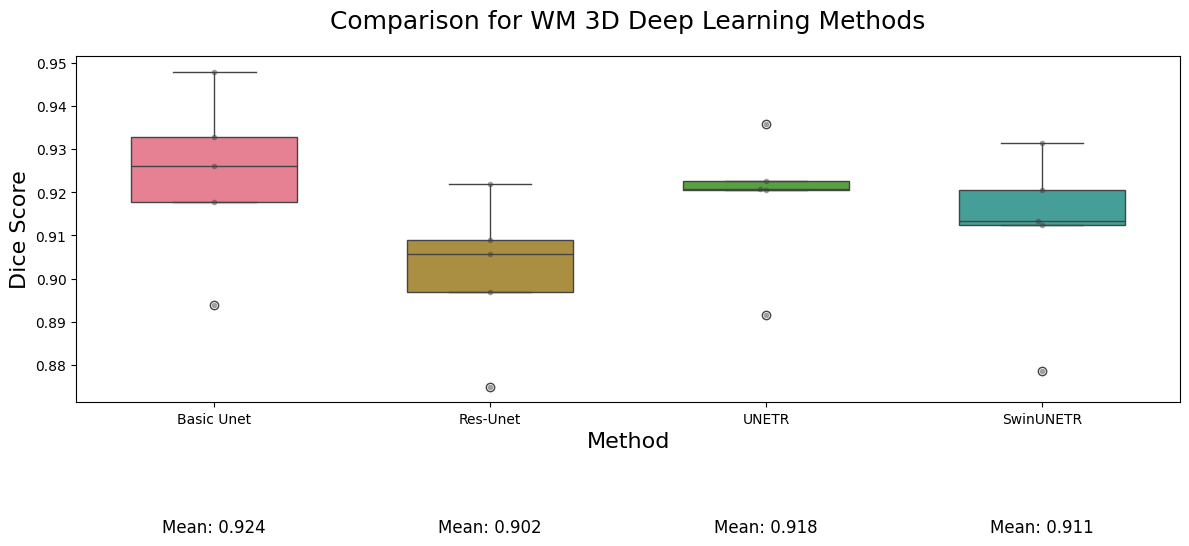

In [11]:
wm_values_unet  = [0.9479,0.9261,0.8940,0.9329,0.9178,]
wm_values_resunet  = [0.9220,0.9056,0.8750,0.9089,0.8969,]
wm_values_unetr = [0.9226,0.9206,0.8916,0.9358,0.9207,]
wm_values_swinunetr = [0.9133,0.9206,0.8787,0.9313,0.9124,]
data = {
    'Basic Unet': wm_values_unet,
    'Res-Unet': wm_values_resunet,
    'UNETR': wm_values_unetr,
    'SwinUNETR': wm_values_swinunetr,

}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for WM 3D Deep Learning Methods', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Method', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.03, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## 2.5D

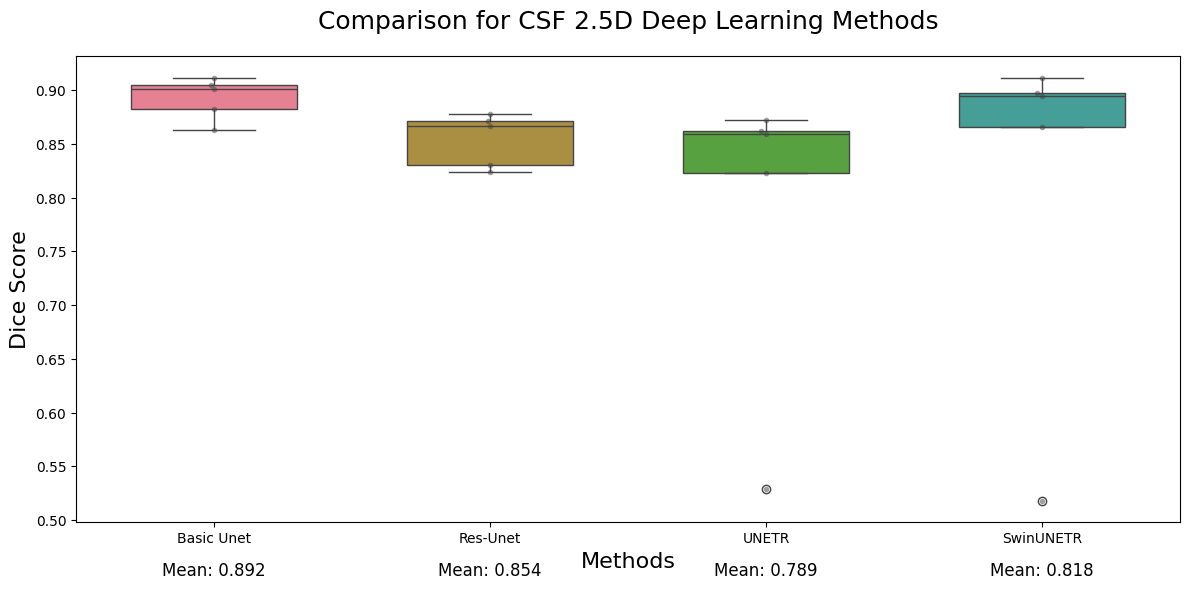

In [15]:
csf_values_unet  = [0.8821,
0.9007,
0.8630,
0.9049,
0.9112,
]
csf_values_resunet = [0.8242,
0.8669,
0.8301,
0.8775,
0.8717,
]
csf_values_unetr = [0.5287,
0.8727,
0.8229,
0.8588,
0.8616,
]
csf_values_swinunetr = [0.5177,
0.8950,
0.8656,
0.9118,
0.8978,
]

data = {
    'Basic Unet': csf_values_unet,
    'Res-Unet': csf_values_resunet,
    'UNETR': csf_values_unetr,
    'SwinUNETR': csf_values_swinunetr,

}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for CSF 2.5D Deep Learning Methods', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Methods', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.05, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

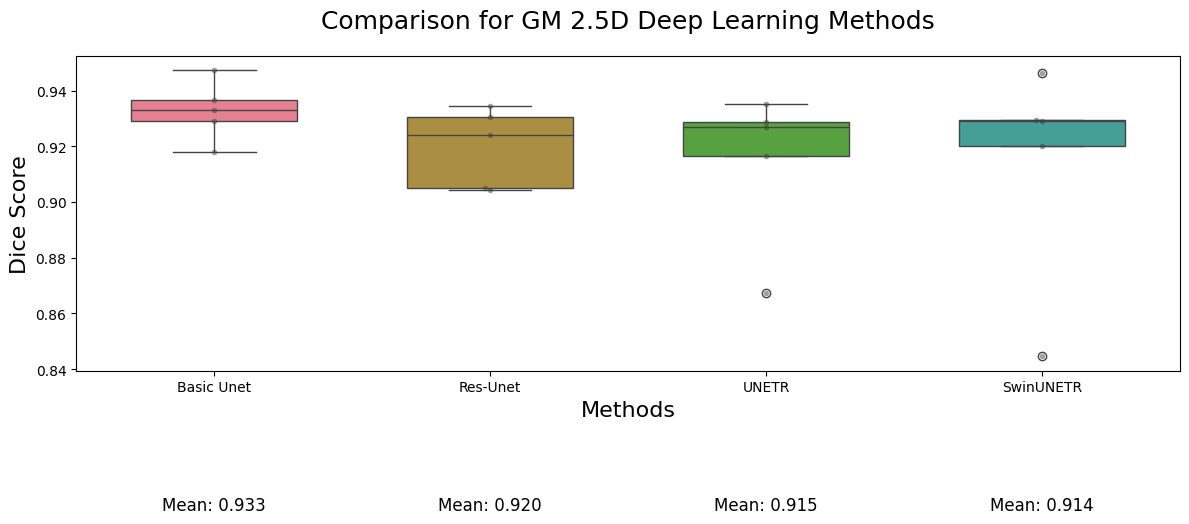

In [16]:
gm_values_unet = [0.9291,
0.9180,
0.9329,
0.9473,
0.9366,
]
gm_values_resunet = [0.9043,
0.9050,
0.9240,
0.9346,
0.9305,
]
gm_values_unetr = [0.8672,
0.9167,
0.9269,
0.9351,
0.9289,
]
gm_values_swinunetr = [0.8446,
0.9201,
0.9292,
0.9462,
0.9294,
]
data = {
    'Basic Unet': gm_values_unet,
    'Res-Unet': gm_values_resunet,
    'UNETR': gm_values_unetr,
    'SwinUNETR': gm_values_swinunetr,

}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for GM 2.5D Deep Learning Methods', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Methods', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.05, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

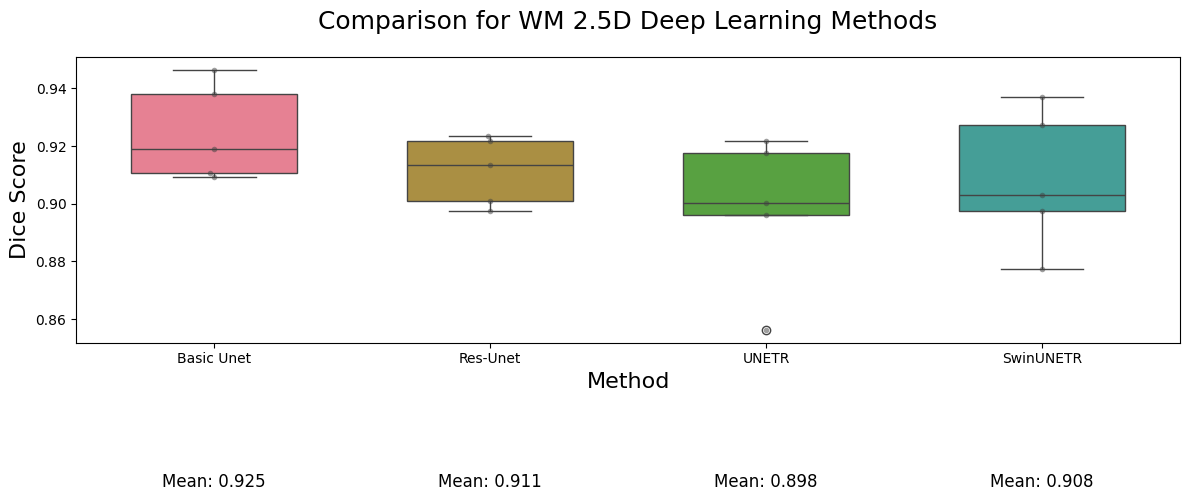

In [17]:
wm_values_unet  = [0.9464,
0.9191,
0.9094,
0.9381,
0.9107,
]
wm_values_resunet  = [0.9236,
0.9134,
0.8975,
0.9218,
0.9010,
]
wm_values_unetr = [0.8564,
0.9216,
0.9002,
0.9177,
0.8962,
]
wm_values_swinunetr = [0.8773,
0.9274,
0.9030,
0.9369,
0.8976,
]
data = {
    'Basic Unet': wm_values_unet,
    'Res-Unet': wm_values_resunet,
    'UNETR': wm_values_unetr,
    'SwinUNETR': wm_values_swinunetr,

}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for WM 2.5D Deep Learning Methods', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Method', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.05, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()